In [18]:
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import skimage

In [19]:
Band2_before = rio.open_rasterio(r"C:\Users\liamt\Downloads\Before Tornado\S2B_MSIL1C_20251107T133139_N0511_R081_T22JCS_20251107T150445.SAFE\GRANULE\L1C_T22JCS_A045295_20251107T133140\IMG_DATA\T22JCS_20251107T133139_B02.jp2")
Band4_before = rio.open_rasterio(r"C:\Users\liamt\Downloads\Before Tornado\S2B_MSIL1C_20251107T133139_N0511_R081_T22JCS_20251107T150445.SAFE\GRANULE\L1C_T22JCS_A045295_20251107T133140\IMG_DATA\T22JCS_20251107T133139_B04.jp2")
Band8_before = rio.open_rasterio(r"C:\Users\liamt\Downloads\Before Tornado\S2B_MSIL1C_20251107T133139_N0511_R081_T22JCS_20251107T150445.SAFE\GRANULE\L1C_T22JCS_A045295_20251107T133140\IMG_DATA\T22JCS_20251107T133139_B08.jp2")

In [20]:
#Band2_before = Band2_before.rio.reproject("EPSG:4326")
#Band4_before = Band4_before.rio.reproject("EPSG:4326")
#Band8 = Band8_before.rio.reproject("EPSG:4326")

In [21]:
Band2 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B02.jp2")
Band4 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B04.jp2")
Band8 = rio.open_rasterio(r"C:\Users\liamt\Downloads\After Tornado\S2B_MSIL1C_20251110T133829_N0511_R124_T22JCS_20251110T165351.SAFE\GRANULE\L1C_T22JCS_A045338_20251110T133912\IMG_DATA\T22JCS_20251110T133829_B08.jp2")

In [22]:
#Band2 = Band2.rio.reproject("EPSG:4326")
#Band4 = Band4.rio.reproject("EPSG:4326")
#Band8 = Band8.rio.reproject("EPSG:4326")

In [32]:
red_in = (Band8/Band4)*0.1
green_in = (Band8_before/Band4_before)*0.09
blue_in = Band2/Band2.max()

In [33]:
red_in = red_in.rio.reproject("EPSG:4326")
green_in = green_in.rio.reproject("EPSG:4326")
blue_in = blue_in.rio.reproject("EPSG:4326")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.8517].


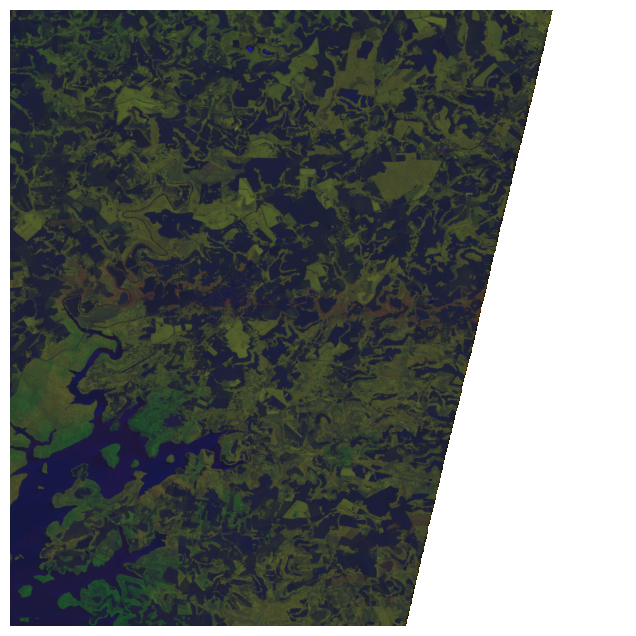

In [31]:
lat_min, lat_max = -25.4, -25.6
lon_min, lon_max = -52.6, -52.4

green = red_in.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
red = green_in.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
blue = blue_in.sel(y=slice(lat_min, lat_max), x=slice(lon_min, lon_max)).squeeze()
rgb = np.dstack((red, green, blue))

# Normalize for display (important!)
rgb_min = 0
rgb_max = 5_000
rgb_scaled = np.clip((rgb - rgb_min) / (rgb_max - rgb_min), 0, 1)

plt.figure(figsize=(8, 8))
plt.imshow(rgb)
plt.axis("off")
plt.show()